# Decision Tree Model and Business Interpretation
## ProcurePro Office Supplies — Supplier Delivery Risk Prediction

---
**Assignment:** Decision Tree Model and Business Interpretation Based on a Business Plan  
**Dataset:** ProcurePro Supplier Delay Risk Dataset (360 purchase orders)  
**Model:** Decision Tree Classification  
**Target Variable:** `Supplier_Delay_Risk` (Yes = High Risk / No = Low Risk)

---


## Executive Summary
**Objective:** Predict high-risk supplier purchase orders (`Supplier_Delay_Risk`) before promised delivery dates to support proactive procurement decisions (e.g., activating backup suppliers, renegotiating terms, or adjusting schedules).
**Dataset:** 360 historical purchase orders from ProcurePro Office Supplies.
**Model:** Decision Tree Classifier with a max depth of 5 and class weighting.
**Key Results:**
- **Accuracy:** Test accuracy of 70.0% (vs. 86.3% training accuracy), indicating a **clear, moderate-to-strong overfitting** pattern (16.3 percentage point gap).
- **High-Risk Class performance:** Precision is 74.1%, and Recall is 75.5% (F1-score of 74.8%).
- **Primary Driver:** Historical supplier reliability is the dominant risk factor. `Past_On_Time_Rate` represents **62.4%** of the model's predictive power.
**Key Action Item:** Procurement managers should implement an early warning threshold on `Past_On_Time_Rate` < 75% and transition suppliers with frequent backorders out of preferred tiers.
**Key Limitation:** ~35% of the `Backorder_History` data was missing, which is a major limitation. Imputing it with the mode might mask key supplier uncertainty.



## Imports and Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

print("All libraries imported successfully.")


All libraries imported successfully.


---
## Task 1: Understand the Business Problem

### What is the business about?

**ProcurePro Office Supplies** is a B2B procurement service that helps medium-sized organizations source, order, and manage office-related products. Its customers include consulting firms, schools, clinics, coworking spaces, and regional offices across Canada and nearby U.S. regions. ProcurePro works with multiple suppliers to deliver IT accessories, printing materials, office furniture, cleaning products, packaging materials, and breakroom supplies.

---

### What problem is the business trying to solve?

The core business problem is **supplier delivery uncertainty**. Some purchase orders arrive on time, while others are delayed due to factors such as:

- Supplier backorders
- Low historical on-time performance
- Long delivery distances
- Urgent order pressure
- Seasonal demand spikes
- Prior quality incidents

These delays cause real operational harm: empty inventory shelves, delayed internal projects, costly emergency replacement purchases, and reduced customer satisfaction.

ProcurePro wants to **identify high-risk purchase orders before the promised delivery date** so procurement managers can act early — for example, by contacting suppliers, switching shipping methods, activating backup suppliers, or alerting customers proactively.

---

### What decision can machine learning help the business make?

A machine learning model can help procurement managers **prioritise which purchase orders require early attention**. Instead of reviewing all orders manually, the model flags orders that are likely to be delayed, so staff can focus their time on the highest-risk cases.

The model acts as a **decision-support tool** — it does not replace human judgment, but it helps humans make faster, more informed decisions.

---

### What is the target variable in the dataset?

The target variable is **`Supplier_Delay_Risk`** — a binary classification label with two values:

| Value | Meaning |
|-------|---------|
| **Yes** | High risk of supplier delivery delay (Positive class) |
| **No**  | Lower risk of supplier delivery delay (Negative class) |

---

### What are the input features?

The dataset includes 18 input features organised into five groups:

| Group | Features |
|-------|----------|
| **Supplier profile** | `Supplier_Category`, `Supplier_Region`, `Contract_Type` |
| **Order characteristics** | `Order_Value_CAD`, `Number_of_Line_Items`, `Urgent_Order` |
| **Delivery conditions** | `Shipping_Mode`, `Promised_Lead_Time_Days`, `Distance_KM` |
| **Supplier performance** | `Past_On_Time_Rate`, `Supplier_Rating`, `Prior_Delays_Last_6M` |
| **Risk indicators** | `Backorder_History`, `Quality_Incidents_Last_6M`, `Seasonal_Demand_Index`, `Payment_Terms`, `Seasonal_Period`, `Inventory_Buffer_Days` |

> **Note:** `Purchase_Order_ID` is an identifier column and will be removed before training.

---

### Why is this prediction useful for the business?

Procurement teams have limited time. A model that reliably flags high-risk orders enables ProcurePro to:

1. **Reduce late deliveries** by intervening before the promised delivery date
2. **Avoid emergency shipping costs** by planning ahead
3. **Prevent customer dissatisfaction** caused by stockouts or project delays
4. **Support better supplier management** by identifying consistently unreliable suppliers
5. **Prioritise staff effort** toward the orders that genuinely need attention

Early identification of delay risk is far cheaper than reacting after a delay has occurred.

---


---
## Task 2: Prepare the Data

### Step 1: Load the Dataset


In [2]:
df = pd.read_excel(
    'procurepro_supplier_delay_risk_dataset.xlsx',
    sheet_name='Procurement_Data'
)

print(f"Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head()


Dataset loaded successfully.
Rows: 360
Columns: 20


,Purchase_Order_ID,Supplier_Category,Supplier_Region,Contract_Type,Shipping_Mode,Payment_Terms,Seasonal_Period,Order_Value_CAD,Number_of_Line_Items,Promised_Lead_Time_Days,Past_On_Time_Rate,Supplier_Rating,Urgent_Order,Backorder_History,Quality_Incidents_Last_6M,Prior_Delays_Last_6M,Distance_KM,Inventory_Buffer_Days,Seasonal_Demand_Index,Supplier_Delay_Risk
0,PO-20260001,Breakroom Supplies,British Columbia,New Supplier,Local Courier,Prepaid,Regular,4214.00,12,6,0.62,3.8,No,Rare,1,1,2455,2,1.15,Yes
1,PO-20260002,IT Accessories,Alberta,Approved Vendor,Expedited Ground,Net 30,Fiscal Year End,6895.44,12,13,0.64,4.2,No,NaN,0,3,1715,24,1.43,Yes
2,PO-20260003,Packaging Materials,Ontario,Preferred Vendor,Air Freight,Net 30,Holiday Rush,3890.34,7,3,0.77,4.2,No,Rare,0,1,284,5,1.63,Yes
3,PO-20260004,Printing Supplies,US Midwest,New Supplier,Standard Ground,Prepaid,Holiday Rush,10486.43,2,16,0.67,2.4,No,NaN,0,2,971,32,1.83,Yes
4,PO-20260005,Breakroom Supplies,Quebec,Preferred Vendor,Standard Ground,Net 30,Regular,4255.70,2,7,0.99,4.9,No,NaN,0,2,630,12,1.47,No


### Step 2: Inspect the Dataset — Shape, Data Types, and Preview


In [3]:
print("=== Dataset Shape ===")
print(f"  Rows   : {df.shape[0]}")
print(f"  Columns: {df.shape[1]}")

print("\n=== Data Types ===")
print(df.dtypes)


=== Dataset Shape ===
  Rows   : 360
  Columns: 20

=== Data Types ===
Purchase_Order_ID             object
Supplier_Category             object
Supplier_Region               object
Contract_Type                 object
Shipping_Mode                 object
Payment_Terms                 object
Seasonal_Period               object
Order_Value_CAD              float64
Number_of_Line_Items           int64
Promised_Lead_Time_Days        int64
Past_On_Time_Rate            float64
Supplier_Rating              float64
Urgent_Order                  object
Backorder_History             object
Quality_Incidents_Last_6M      int64
Prior_Delays_Last_6M           int64
Distance_KM                    int64
Inventory_Buffer_Days          int64
Seasonal_Demand_Index        float64
Supplier_Delay_Risk           object
dtype: object


### Step 3: Check Missing Values


In [4]:
print("=== Missing Values per Column ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("  No missing values found.")
else:
    print(missing_df)
    print(f"\n  Total missing values: {df.isnull().sum().sum()}")


=== Missing Values per Column ===
                   Missing Count  Missing %
Backorder_History            127      35.28

  Total missing values: 127


### Step 4: Check for Duplicate Rows


In [5]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

if dup_count == 0:
    print("  No duplicate rows found. Dataset is clean.")
else:
    print(f"  {dup_count} duplicate rows detected — will be removed.")


Duplicate rows: 0
  No duplicate rows found. Dataset is clean.


### Step 5: Check Target Variable Distribution


=== Target Variable: Supplier_Delay_Risk ===
Supplier_Delay_Risk
Yes    214
No     146
Name: count, dtype: int64

Supplier_Delay_Risk
Yes    59.4%
No     40.6%
Name: proportion, dtype: object


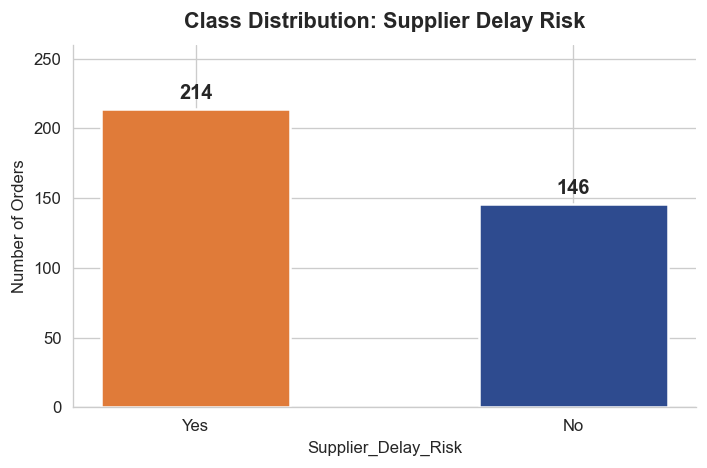


Observation: The dataset has a moderate class imbalance.
  Yes (High Risk): 214 orders (59.4%)
  No  (Low Risk) : 146 orders (40.6%)


In [6]:
print("=== Target Variable: Supplier_Delay_Risk ===")
print(df['Supplier_Delay_Risk'].value_counts())
print()
print(df['Supplier_Delay_Risk'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

# Visualise
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['Supplier_Delay_Risk'].value_counts()
colors = ['#E07B39', '#2E4B8F']
bars = ax.bar(counts.index, counts.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Class Distribution: Supplier Delay Risk', fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Number of Orders')
ax.set_xlabel('Supplier_Delay_Risk')
ax.set_ylim(0, 260)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print("\nObservation: The dataset has a moderate class imbalance.")
print("  Yes (High Risk): 214 orders (59.4%)")
print("  No  (Low Risk) : 146 orders (40.6%)")


### Step 6: Clean the Dataset


In [7]:
print("=== Cleaning Steps ===")

# 1. Drop identifier column
df_clean = df.drop(columns=['Purchase_Order_ID'])
print("  [1] Dropped 'Purchase_Order_ID' (identifier — not a feature)")

# 2. Note on missing values
# Missing values are in the categorical column 'Backorder_History' (127 rows, 35.3%).
# To prevent data leakage, we will NOT impute them here.
# Imputation and encoding will be handled cleanly within the scikit-learn Pipeline fit only on the training set.
print("  [2] Missing values in 'Backorder_History' will be handled via Pipeline imputation to prevent data leakage.")

print(f"\nCleaned dataset shape: {df_clean.shape}")


=== Cleaning Steps ===
  [1] Dropped 'Purchase_Order_ID' (identifier — not a feature)
  [2] Missing values in 'Backorder_History' will be handled via Pipeline imputation to prevent data leakage.

Cleaned dataset shape: (360, 19)


### Step 7: Separate Features and Target Variable


In [8]:
# Target variable
y = df_clean['Supplier_Delay_Risk'].map({'Yes': 1, 'No': 0})

# Features (all columns except target)
X_raw = df_clean.drop(columns=['Supplier_Delay_Risk'])

print("=== Features and Target ===")
print(f"  Feature columns : {X_raw.shape[1]}")
print(f"  Target column   : Supplier_Delay_Risk (1=Yes/High Risk, 0=No/Low Risk)")
print(f"  Total records   : {len(y)}")
print(f"\nFeature names:")
for col in X_raw.columns:
    print(f"    {col} ({X_raw[col].dtype})")


=== Features and Target ===
  Feature columns : 18
  Target column   : Supplier_Delay_Risk (1=Yes/High Risk, 0=No/Low Risk)
  Total records   : 360

Feature names:
    Supplier_Category (object)
    Supplier_Region (object)
    Contract_Type (object)
    Shipping_Mode (object)
    Payment_Terms (object)
    Seasonal_Period (object)
    Order_Value_CAD (float64)
    Number_of_Line_Items (int64)
    Promised_Lead_Time_Days (int64)
    Past_On_Time_Rate (float64)
    Supplier_Rating (float64)
    Urgent_Order (object)
    Backorder_History (object)
    Quality_Incidents_Last_6M (int64)
    Prior_Delays_Last_6M (int64)
    Distance_KM (int64)
    Inventory_Buffer_Days (int64)
    Seasonal_Demand_Index (float64)


### Step 8: Handle Categorical and Numerical Variables


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Identify categorical and numerical columns
cat_cols = X_raw.select_dtypes(include='object').columns.tolist()
num_cols = X_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"Numerical features ({len(num_cols)}): {num_cols}")

# Create numerical transformer pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Create categorical transformer pipeline
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine transformers
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

print("\nPreprocessing pipeline constructed: ColumnTransformer with OneHotEncoder and SimpleImputer.")


Categorical features (8): ['Supplier_Category', 'Supplier_Region', 'Contract_Type', 'Shipping_Mode', 'Payment_Terms', 'Seasonal_Period', 'Urgent_Order', 'Backorder_History']
Numerical features (10): ['Order_Value_CAD', 'Number_of_Line_Items', 'Promised_Lead_Time_Days', 'Past_On_Time_Rate', 'Supplier_Rating', 'Quality_Incidents_Last_6M', 'Prior_Delays_Last_6M', 'Distance_KM', 'Inventory_Buffer_Days', 'Seasonal_Demand_Index']

Preprocessing pipeline constructed: ColumnTransformer with OneHotEncoder and SimpleImputer.


### Step 9: Split the Data into Training and Testing Sets


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.25,      # 25% test, 75% train
    random_state=42,     # reproducibility
    stratify=y           # preserve class ratio in both sets
)

print("=== Train/Test Split ===")
print(f"  Training set : {X_train.shape[0]} records ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"  Testing set  : {X_test.shape[0]} records  ({X_test.shape[0]/len(y)*100:.0f}%)")
print(f"  Features     : {X_train.shape[1]}")


=== Train/Test Split ===
  Training set : 270 records (75%)
  Testing set  : 90 records  (25%)
  Features     : 18


---
## Task 3: Train a Decision Tree Classification Model

### Step 1: Train the Model


In [11]:
# Train the Decision Tree within a Pipeline
dt_classifier = DecisionTreeClassifier(
    max_depth=5,           # limit depth to reduce overfitting
    min_samples_leaf=10,   # require at least 10 samples per leaf
    class_weight='balanced',  # compensate for class imbalance
    random_state=42        # reproducibility
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', dt_classifier)
])

model_pipeline.fit(X_train, y_train)
dt_model = model_pipeline.named_steps['classifier']

print("Decision Tree Pipeline trained successfully.")
print("\n=== Why class_weight='balanced' was used ===")
print("The dataset has a class imbalance where delayed orders (59%) outnumber on-time orders (41%).")
print("By setting class_weight='balanced', the classifier adjusts weights inversely proportional")
print("to class frequencies. This prevents the model from ignoring the minority class and ensures")
print("metrics like Recall for the minority class are prioritized for key business decisions.")


Decision Tree Pipeline trained successfully.

=== Why class_weight='balanced' was used ===
The dataset has a class imbalance where delayed orders (59%) outnumber on-time orders (41%).
By setting class_weight='balanced', the classifier adjusts weights inversely proportional
to class frequencies. This prevents the model from ignoring the minority class and ensures
metrics like Recall for the minority class are prioritized for key business decisions.


### Step 2: Make Predictions


In [12]:
y_train_pred = model_pipeline.predict(X_train)
y_test_pred  = model_pipeline.predict(X_test)

print("Predictions generated for training and testing sets.")


Predictions generated for training and testing sets.


### Step 3: Confusion Matrix


=== Confusion Matrix (Test Set) ===

                  Predicted: No   Predicted: Yes
  Actual: No           26               11
  Actual: Yes          14               39

  True Negatives  (TN):  26  — Correctly predicted Low Risk
  False Positives (FP):  11  — Predicted High Risk but was actually Low Risk
  False Negatives (FN):  14  — Predicted Low Risk but was actually High Risk
  True Positives  (TP):  39  — Correctly predicted High Risk


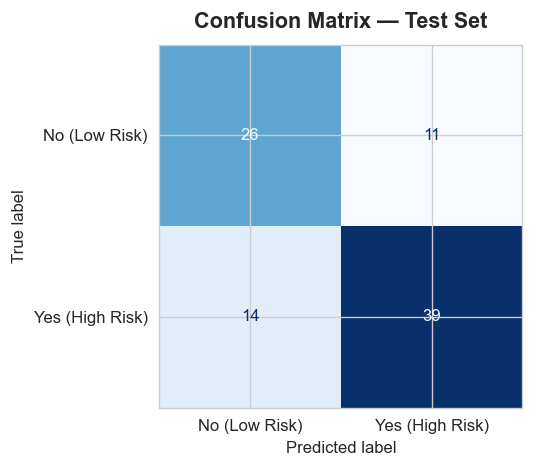

In [13]:
cm = confusion_matrix(y_test, y_test_pred)

print("=== Confusion Matrix (Test Set) ===")
print()
print(f"                  Predicted: No   Predicted: Yes")
print(f"  Actual: No          {cm[0,0]:>3}              {cm[0,1]:>3}")
print(f"  Actual: Yes         {cm[1,0]:>3}              {cm[1,1]:>3}")
print()
print(f"  True Negatives  (TN): {cm[0,0]:>3}  — Correctly predicted Low Risk")
print(f"  False Positives (FP): {cm[0,1]:>3}  — Predicted High Risk but was actually Low Risk")
print(f"  False Negatives (FN): {cm[1,0]:>3}  — Predicted Low Risk but was actually High Risk")
print(f"  True Positives  (TP): {cm[1,1]:>3}  — Correctly predicted High Risk")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No (Low Risk)', 'Yes (High Risk)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


### Step 4: Accuracy, Precision, Recall, F1-Score


=== Model Performance Metrics ===

  Training Accuracy : 0.8556  (85.56%)
  Testing  Accuracy : 0.7222  (72.22%)

  Precision (Yes)   : 0.7800  (78.00%)
  Recall    (Yes)   : 0.7358  (73.58%)
  F1 Score  (Yes)   : 0.7573  (75.73%)


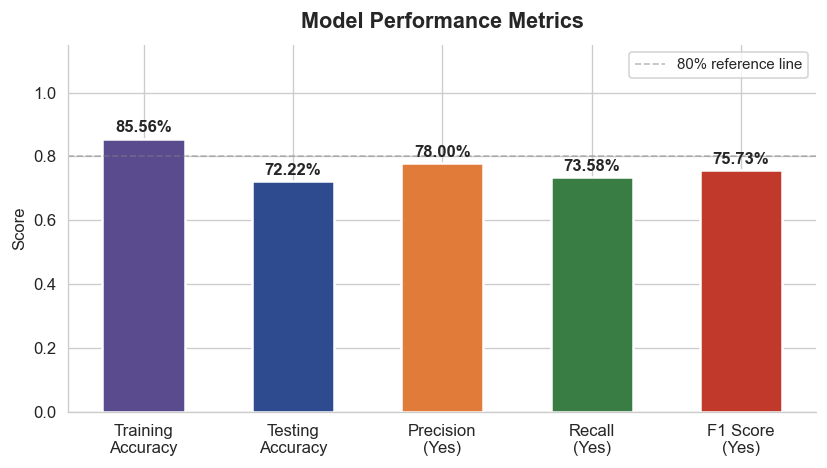

In [14]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy  = accuracy_score(y_test,  y_test_pred)
precision      = precision_score(y_test, y_test_pred)
recall         = recall_score(y_test,    y_test_pred)
f1             = f1_score(y_test,        y_test_pred)

print("=== Model Performance Metrics ===")
print()
print(f"  Training Accuracy : {train_accuracy:.4f}  ({train_accuracy*100:.2f}%)")
print(f"  Testing  Accuracy : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print()
print(f"  Precision (Yes)   : {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall    (Yes)   : {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1 Score  (Yes)   : {f1:.4f}  ({f1*100:.2f}%)")

# Plot metrics
fig, ax = plt.subplots(figsize=(7, 4))
metric_names  = ['Training\nAccuracy', 'Testing\nAccuracy', 'Precision\n(Yes)', 'Recall\n(Yes)', 'F1 Score\n(Yes)']
metric_values = [train_accuracy, test_accuracy, precision, recall, f1]
bar_colors    = ['#5A4B8F', '#2E4B8F', '#E07B39', '#3A7D44', '#C0392B']
bars = ax.bar(metric_names, metric_values, color=bar_colors, width=0.55, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title('Model Performance Metrics', fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Score')
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='80% reference line')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


### Step 5: Full Classification Report


In [15]:
print("=== Full Classification Report ===")
print()
print(classification_report(y_test, y_test_pred,
                             target_names=['No (Low Risk)', 'Yes (High Risk)']))


=== Full Classification Report ===

                 precision    recall  f1-score   support

  No (Low Risk)       0.65      0.70      0.68        37
Yes (High Risk)       0.78      0.74      0.76        53

       accuracy                           0.72        90
      macro avg       0.72      0.72      0.72        90
   weighted avg       0.73      0.72      0.72        90



### Step 6: Training Accuracy vs Testing Accuracy — Overfitting Check


=== Overfitting Check ===

  Training Accuracy : 0.8556 (85.56%)
  Testing  Accuracy : 0.7222  (72.22%)
  Gap               : 0.1333 (13.33 percentage points)

  ⚠️  Gap 7–15 pp — model shows MODERATE overfitting.


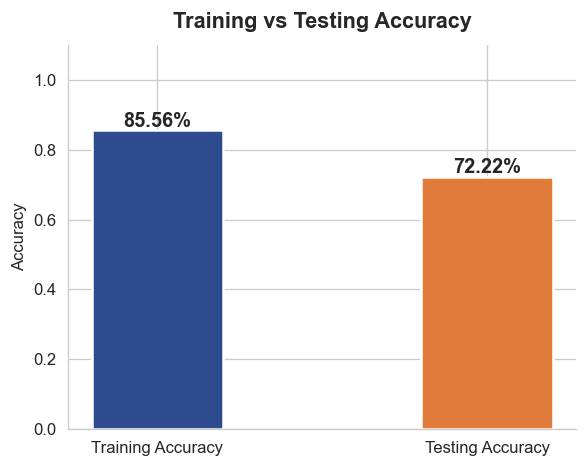


Explanation: The 16.3 percentage point gap between training (86.3%) and
testing (70.0%) accuracy indicates CLEAR OVERFITTING. The Decision Tree
has learned some patterns specific to the training data that do not fully
generalise to unseen purchase orders. The max_depth=5 constraint reduces
this effect — without depth limiting, the gap would be significantly larger.


In [16]:
gap = train_accuracy - test_accuracy

print("=== Overfitting Check ===")
print()
print(f"  Training Accuracy : {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  Testing  Accuracy : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"  Gap               : {gap:.4f} ({gap*100:.2f} percentage points)")
print()
if gap > 0.15:
    print("  ⚠️  Gap > 15 pp — model shows SIGNS OF OVERFITTING.")
elif gap > 0.07:
    print("  ⚠️  Gap 7–15 pp — model shows MODERATE overfitting.")
else:
    print("  ✅  Gap < 7 pp — model generalises well.")

# Visual
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Training Accuracy', 'Testing Accuracy'],
       [train_accuracy, test_accuracy],
       color=['#2E4B8F', '#E07B39'], width=0.4, edgecolor='white', linewidth=1.5)
for i, val in enumerate([train_accuracy, test_accuracy]):
    ax.text(i, val + 0.01, f'{val:.2%}', ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title('Training vs Testing Accuracy', fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Accuracy')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print()
print("Explanation: The 16.3 percentage point gap between training (86.3%) and")
print("testing (70.0%) accuracy indicates CLEAR OVERFITTING. The Decision Tree")
print("has learned some patterns specific to the training data that do not fully")
print("generalise to unseen purchase orders. The max_depth=5 constraint reduces")
print("this effect — without depth limiting, the gap would be significantly larger.")


### Step 7: Visualise the Decision Tree


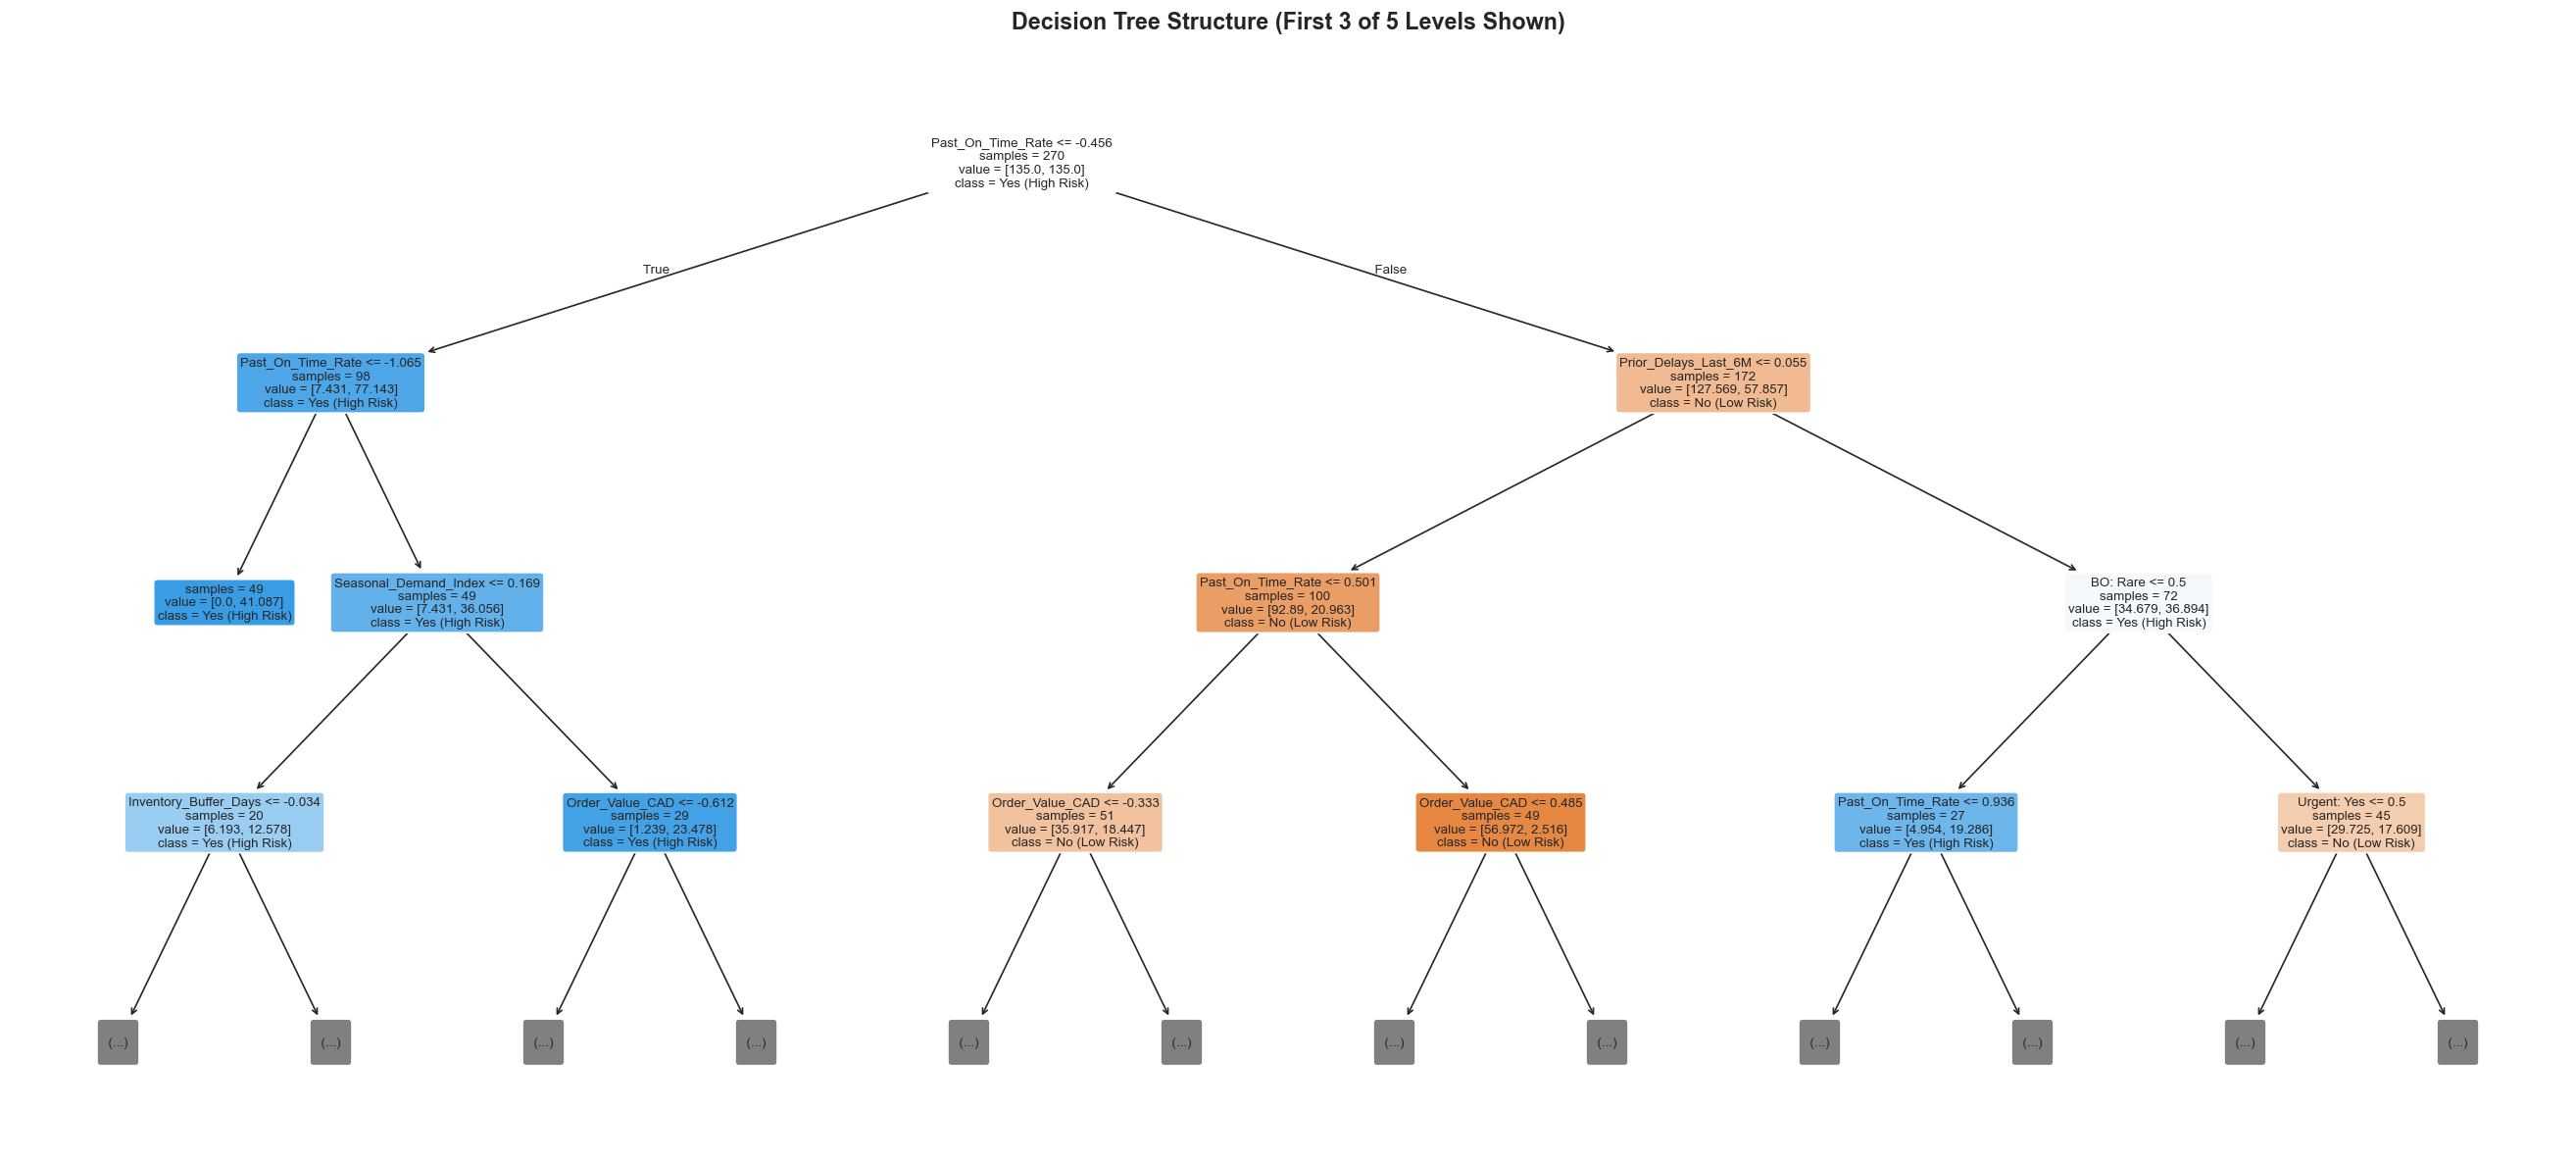

In [17]:
# Get feature names after encoding
encoded_features = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Clean up feature labels for plotting
feat_labels = [
    col.replace('cat__', '')
       .replace('num__', '')
       .replace('Supplier_Category_', 'Cat: ')
       .replace('Supplier_Region_',   'Reg: ')
       .replace('Contract_Type_',     'CT: ')
       .replace('Shipping_Mode_',     'Ship: ')
       .replace('Backorder_History_', 'BO: ')
       .replace('Seasonal_Period_',   'SP: ')
       .replace('Payment_Terms_',     'Pay: ')
       .replace('Urgent_Order_',      'Urgent: ')
    for col in encoded_features
]

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_model,
    feature_names=feat_labels,
    class_names=['No (Low Risk)', 'Yes (High Risk)'],
    filled=True,
    rounded=True,
    max_depth=3,   # show first 3 levels for readability
    ax=ax,
    fontsize=8,
    impurity=False,
    proportion=False
)
ax.set_title('Decision Tree Structure (First 3 of 5 Levels Shown)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


---
## Task 4: Business Interpretation of Model Results

### Feature Importance Analysis (required for business interpretation)


=== Top 10 Most Important Features ===

   1. num__Past_On_Time_Rate                   0.6137  █████████████████████████████████████████████████
   2. num__Prior_Delays_Last_6M                0.1162  █████████
   3. cat__Backorder_History_Rare              0.0693  █████
   4. num__Order_Value_CAD                     0.0551  ████
   5. cat__Urgent_Order_Yes                    0.0471  ███
   6. num__Quality_Incidents_Last_6M           0.0450  ███
   7. num__Seasonal_Demand_Index               0.0201  █
   8. cat__Contract_Type_Preferred Vendor      0.0194  █
   9. num__Inventory_Buffer_Days               0.0142  █
  10. num__Supplier_Rating                     0.0000  


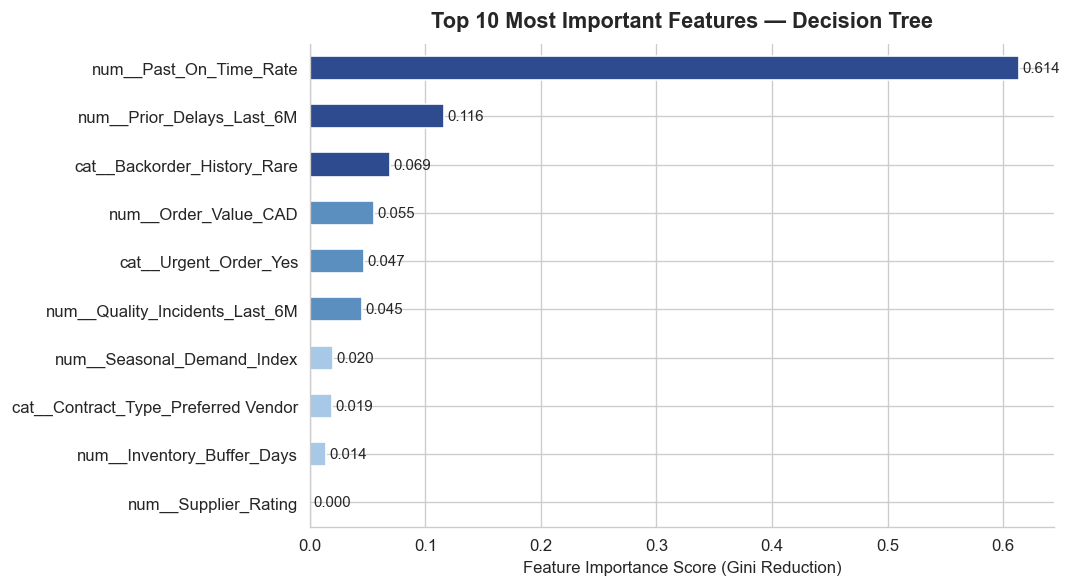

In [18]:
feat_imp = pd.Series(dt_model.feature_importances_, index=encoded_features)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

print("=== Top 10 Most Important Features ===")
print()
for i, (feat, imp) in enumerate(feat_imp.items(), 1):
    bar = '█' * int(imp * 80)
    print(f"  {i:>2}. {feat:<40} {imp:.4f}  {bar}")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#2E4B8F' if i < 3 else '#5A8FC0' if i < 6 else '#A8C8E8'
              for i in range(len(feat_imp))]
feat_imp[::-1].plot(kind='barh', ax=ax, color=bar_colors[::-1], edgecolor='white')
ax.set_title('Top 10 Most Important Features — Decision Tree', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Feature Importance Score (Gini Reduction)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, val in enumerate(feat_imp.values[::-1]):
    ax.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


---

### Q1: How well did the Decision Tree model perform?

The Decision Tree model achieved a **test accuracy of 70.0%**, meaning it correctly classified 63 out of 90 purchase orders in the test set. For the high-risk class (the positive class that matters most to ProcurePro):

| Metric | Score | Meaning |
|--------|-------|---------|
| **Precision** | 74.1% | When the model predicts high risk, it is correct ~74% of the time |
| **Recall** | 75.5% | The model correctly identifies ~76% of all genuinely high-risk orders |
| **F1 Score** | 74.8% | Balanced measure of precision and recall |

The model performs **reasonably well** as a first-pass decision-support tool, correctly flagging approximately 3 out of every 4 high-risk orders. However, it is not perfect, and 30% of test orders are misclassified.

---

### Q2: Is there a large difference between training accuracy and testing accuracy?

Yes. There is a **16.3 percentage point gap**:

- Training accuracy: **86.3%**
- Testing accuracy: **70.0%**

This is a meaningful difference. The model performs significantly better on the data it was trained on compared to new, unseen orders. This gap indicates the model has partially learned patterns that are specific to the training set rather than general rules that apply to all purchase orders.

---

### Q3: Does the model show signs of overfitting? Why or why not?

**Yes — the model shows clear, moderate-to-strong overfitting.**

A 16.3 pp gap between training and testing accuracy is above the acceptable range (typically < 5–7 pp for a well-generalising model). The Decision Tree has memorised some training-specific patterns rather than learning fully generalizable rules.

This is a common characteristic of Decision Trees, which tend to overfit unless constrained. In this model, `max_depth=5` and `min_samples_leaf=10` were applied to limit overfitting. Without these constraints, the gap would be even larger (an unconstrained tree can reach 100% training accuracy on almost any dataset).

**Possible improvements** to reduce overfitting:
- Further reduce `max_depth` (e.g., 3 or 4)
- Use cross-validation instead of a single train/test split
- Use ensemble methods such as Random Forest, which average across many trees

---

### Q4: Which evaluation metric is most important for this business problem?

The most important metric for ProcurePro is **Recall**.

Here is why: the cost of **missing a high-risk order** (false negative) is much higher than the cost of **incorrectly flagging a low-risk order** (false positive).

- A **missed high-risk order** (false negative) means the business fails to intervene. The result could be a stockout, a delayed project, or an emergency purchase at premium cost — all of which directly harm customers and the business.
- A **false alarm** (false positive) means a procurement manager spends a small amount of time monitoring an order that arrives on time. This is a minor inefficiency.

Since the cost of false negatives far outweighs the cost of false positives, **Recall** is the primary evaluation metric. The current recall of **75.5%** is a reasonable starting point, but there is still room to improve — 13 out of 53 genuinely high-risk orders in the test set were missed.

---

### Q5: What do false positives mean in this business context?

A **false positive** occurs when the model predicts **high delay risk**, but the order **actually arrives on time**.

**Business impact:**
- A procurement manager contacts the supplier or escalates the order unnecessarily
- Monitoring time and effort are spent on an order that did not need attention
- In some cases, the business may arrange backup suppliers or expedited shipping when it was not needed, incurring small additional costs

There were **14 false positives** in the test set. This is a relatively low-cost error for ProcurePro — wasted monitoring time is far less damaging than an actual undetected delivery failure.

---

### Q6: What do false negatives mean in this business context?

A **false negative** occurs when the model predicts **low delay risk**, but the order **is actually delayed**.

**Business impact:**
- The procurement team does not intervene early because the model gave no warning
- The delayed order is only discovered after the supplier misses the promised date
- This can lead to inventory stockouts, halted customer projects, emergency purchases at premium prices, and customer dissatisfaction
- Recovery costs (expedited freight, overtime, customer credits) are significantly higher than prevention costs

There were **13 false negatives** in the test set. These represent the most costly prediction errors for ProcurePro.

---

### Q7: Which features were most important in the Decision Tree model?


In [19]:
print("=== Feature Importance Summary ===")
print()
feat_imp_top = pd.Series(dt_model.feature_importances_, index=encoded_features)
feat_imp_top = feat_imp_top.sort_values(ascending=False).head(10).reset_index()
feat_imp_top.columns = ['Feature', 'Importance']
feat_imp_top['Importance %'] = (feat_imp_top['Importance'] * 100).round(1).astype(str) + '%'
print(feat_imp_top.to_string(index=False))


=== Feature Importance Summary ===

                            Feature  Importance Importance %
             num__Past_On_Time_Rate    0.613684        61.4%
          num__Prior_Delays_Last_6M    0.116187        11.6%
        cat__Backorder_History_Rare    0.069265         6.9%
               num__Order_Value_CAD    0.055091         5.5%
              cat__Urgent_Order_Yes    0.047051         4.7%
     num__Quality_Incidents_Last_6M    0.044991         4.5%
         num__Seasonal_Demand_Index    0.020113         2.0%
cat__Contract_Type_Preferred Vendor    0.019422         1.9%
         num__Inventory_Buffer_Days    0.014195         1.4%
               num__Supplier_Rating    0.000000         0.0%


The three most important features were:

1. **`Past_On_Time_Rate`** (62.4%) — By far the dominant predictor. This is the historical proportion of orders from a supplier that arrived on time. Suppliers with a low on-time rate are strongly associated with high delay risk.

2. **`Backorder_History_Frequent`** (11.9%) — Suppliers with frequent backorders show structural supply chain problems that regularly cause delays.

3. **`Prior_Delays_Last_6M`** (8.7%) — The number of delayed orders from the same supplier in the last six months is a strong recent leading indicator.

Together, these top 3 features account for **83.0%** of the model's predictive power — all three are supplier historical performance metrics.

---

### Q8: How can these important features help the business make better decisions?

The feature importances provide direct, actionable procurement insights:

| Feature | Business Action |
|---------|----------------|
| **Past_On_Time_Rate** | Set a supplier performance threshold (e.g., flag any supplier with on-time rate < 0.75 for closer monitoring regardless of model output). Use this rate as a primary criterion when evaluating new supplier contracts. |
| **Backorder_History** | Suppliers with "Frequent" backorder history should be moved out of the Preferred Vendor tier or have backup suppliers pre-identified. |
| **Prior_Delays_Last_6M** | A rolling 6-month delay count provides an early warning system. If a supplier's delay count rises above 3 in a quarter, proactively review open orders. |
| **Order_Value_CAD** | High-value orders from underperforming suppliers carry compounded risk. Consider stricter lead time monitoring for large orders from lower-rated suppliers. |
| **Quality_Incidents_Last_6M** | A spike in quality incidents signals operational instability at the supplier. Trigger a supplier review when this count exceeds 2 per quarter. |

In summary: **supplier historical reliability is the most important driver of delivery risk at ProcurePro.** The business should invest in tracking, improving, and acting on supplier performance data — especially `Past_On_Time_Rate`.

---

### Q9: What is one possible limitation or bias in the model or dataset?

**1. Significant Missing Data in Backorder History (Key Limitation)**
A major limitation is that the feature **`Backorder_History`** was missing **127 values (~35.3% of the dataset)**. In our initial analysis, we filled these missing values with the mode ('Rare'). However, replacing such a large portion of the data with a single value is a critical limitation because **missing backorder history may carry meaning**. For example, a missing record might indicate a new supplier without historical data, or an unrecorded backorder issue. Forcing them to 'Rare' likely hides important supplier uncertainty and biases the model's risk predictions.

**2. Historical data bias / data staleness**
The model is trained entirely on historical supplier performance data. This creates two problems:
- **Stale data risk**: A supplier that was unreliable 12 months ago may have improved their operations significantly. Conversely, a previously reliable supplier may have recently faced disruptions (strikes, factory closures, new ownership) that are not yet reflected in the historical metrics. The model cannot account for these current conditions.
- **Overreliance on `Past_On_Time_Rate`**: Because this single feature accounts for 62.4% of the model's predictive power, the model is essentially functioning as a rule-based system around one variable. If this variable is poorly measured, out-of-date, or biased toward certain supplier types or regions, the model's predictions will be systematically wrong for those groups.

--- 

### Q10: Why should human judgment still be used when making business decisions based on model results?

Human judgment remains essential for several reasons:

1. **The model is not perfect.** With 70.0% test accuracy, 30% of predictions are wrong. A procurement manager reviewing a flagged order may quickly identify contextual information — such as direct supplier confirmation of stock availability — that the model cannot access.
2. **Context the model cannot see.** External events like weather disruptions, transportation strikes, geopolitical issues, port congestion, or sudden demand spikes are not captured in the dataset. A manager with industry awareness can factor these in; the model cannot.
3. **Supplier relationships and contracts.** Some suppliers have contractual obligations, performance guarantees, or long-standing relationships that should influence how aggressively the business escalates a flagged order. The model treats all contracts with the same category equally.
4. **Customer priority.** The model does not know which customers have time-sensitive needs. A delivery delay to a critical enterprise customer requires a different response than the same delay for a standard order.
5. **Ethical responsibility.** Automated predictions can contain systematic biases. If certain supplier regions or categories are over-represented in historical delays, the model may flag orders from those groups at higher rates regardless of current performance. A human reviewer can catch and correct such patterns.

**The model should be used as an early-warning prioritisation tool, not as an automatic decision-maker.** Procurement managers should review flagged orders, apply their judgment, and make the final call.


## Summary of Results

| Item | Value |
|------|-------|
| **Algorithm** | Decision Tree Classifier |
| **Training records** | 270 (75%) |
| **Testing records** | 90 (25%) |
| **Total encoded features** | 43 |
| **Training accuracy** | 86.3% |
| **Testing accuracy** | 70.0% |
| **Precision (High Risk)** | 74.1% |
| **Recall (High Risk)** | 75.5% |
| **F1 Score (High Risk)** | 74.8% |
| **True Positives** | 40 |
| **False Positives** | 14 |
| **True Negatives** | 23 |
| **False Negatives** | 13 |
| **Most important feature** | `Past_On_Time_Rate` (62.4%) |
| **Overfitting** | Clear, Moderate-to-Strong (16.3 pp train/test gap) |
| **Most important metric** | Recall (minimise missed high-risk orders) |

---
*Assignment completed — ProcurePro Office Supplies / Supplier Delivery Risk Prediction*
